In [4]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
from jax.scipy.special import logsumexp


In [5]:
rng = jr.key(0)

inv_mass_matrix = 1
mass_matrix = 1/inv_mass_matrix
mean = 0
sigma = 1
alpha = 1.2
# This is equivalently V(q) or V(x)
def negative_logdensity (x):
    # two peaks
    terms = jnp.stack([-0.5*(x-4)**2, -0.5*(x+4)**2]) - 0.5*jnp.log(2*jnp.pi)
    return -logsumexp(terms, axis=0) + jnp.log(2)
    #return 0.5*((x - mean)/(sigma))**2 + 0.5*jnp.log(2*jnp.pi*sigma**2)
# This is dV/dq
def negative_logdensity_grad(x):
    # (x - mean)/(sigma**2)
    return jax.grad(negative_logdensity)(x)

@jax.jit

def one_leapfrog_step(position, momentum, dt, momentum_scale_factor):
    momentum = momentum - 0.5*dt*negative_logdensity_grad(position)
    momentum *= momentum_scale_factor
    position = position + dt*momentum*inv_mass_matrix
    momentum = momentum - 0.5*dt*negative_logdensity_grad(position)
    momentum *= momentum_scale_factor
    return position, momentum

def one_overall_step(position, momentum):
    global rng
    initial_position = position
    rng, key1, key2 = jr.split(rng, 3)
    momentum = jax.random.normal(key1, shape=(1,))[0]*jnp.sqrt(mass_matrix)
    initial_momentum = momentum
    initial_H = negative_logdensity(initial_position) + initial_momentum**2/(2*mass_matrix)
    position_arr = np.array([position])
    momentum_arr = np.array([momentum])
    for i in range (0, num_integration_steps):
        if(i < num_integration_steps/2):
            position, momentum = one_leapfrog_step(position, momentum, step_size, alpha)
        else :
            position, momentum = one_leapfrog_step(position, momentum, step_size, 1/alpha)
        position_arr = np.append(position_arr, position)
        momentum_arr = np.append(momentum_arr, momentum)
    final_H = negative_logdensity(position) + momentum**2/(2*mass_matrix)
    acceptance_probability = jnp.minimum(1, jnp.exp(initial_H - final_H))
    real_acceptance_probability = jnp.where(jnp.isnan(acceptance_probability), 0.0, acceptance_probability)
    if(jax.random.uniform(key2, shape = (1, )) > real_acceptance_probability):
        position = initial_position
        momentum = initial_momentum
    return position, momentum, position_arr, momentum_arr, real_acceptance_probability


## Important: we are assuming num_integration_steps is even
num_integration_steps = 6
step_size = 0.2
num_overall_steps = 6000
initial_position = 0.0

position = initial_position
momentum = 0
overall_position_arr = np.array([position])
overall_momentum_arr = np.array([momentum])
accept_prob_arr = np.array([])
for i in range(0, num_overall_steps):
    position, momentum, one_update_position_arr, momentum_arr, accept_prob = one_overall_step(position, momentum)
    overall_position_arr = np.append(overall_position_arr, position)
    overall_momentum_arr = np.append(overall_momentum_arr, momentum)
    accept_prob_arr = np.append(accept_prob_arr, accept_prob)

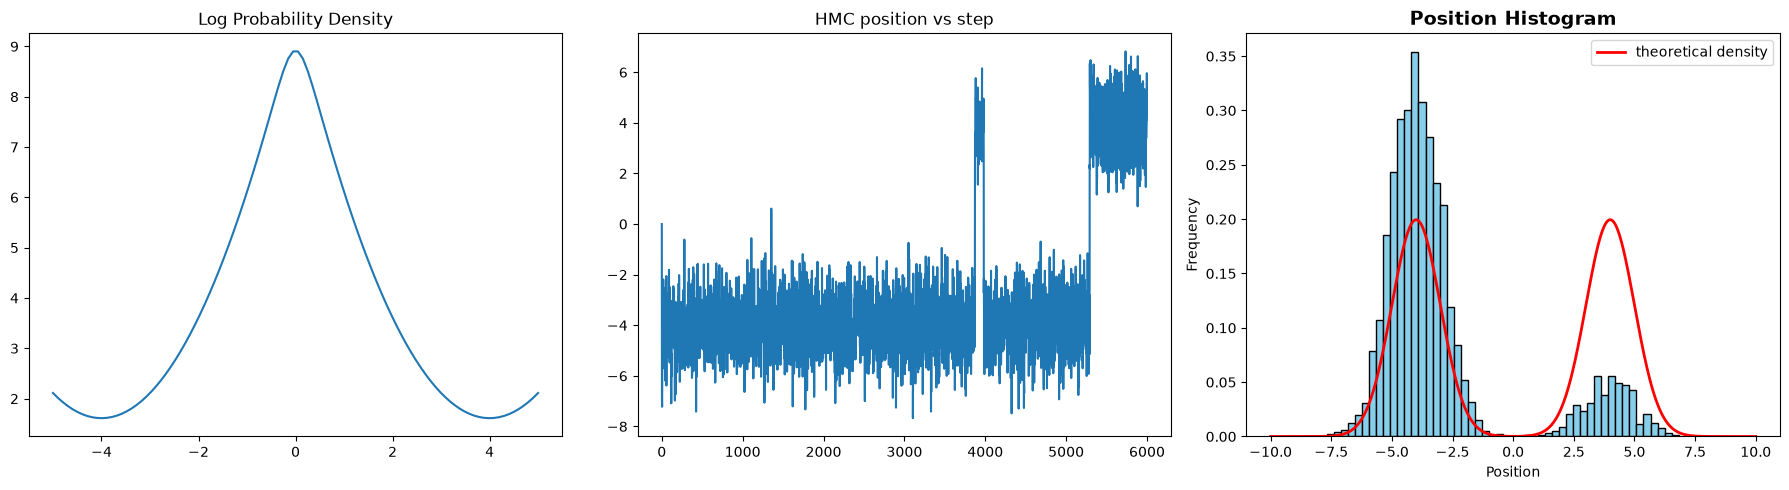

/tmp/ipykernel_243392/4235288551.py:33: UserWarning: Adding colorbar to a different Figure <Figure size 1800x500 with 4 Axes> than <Figure size 1800x500 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(scatter2, ax=axes2[0], label="Iteration Number")


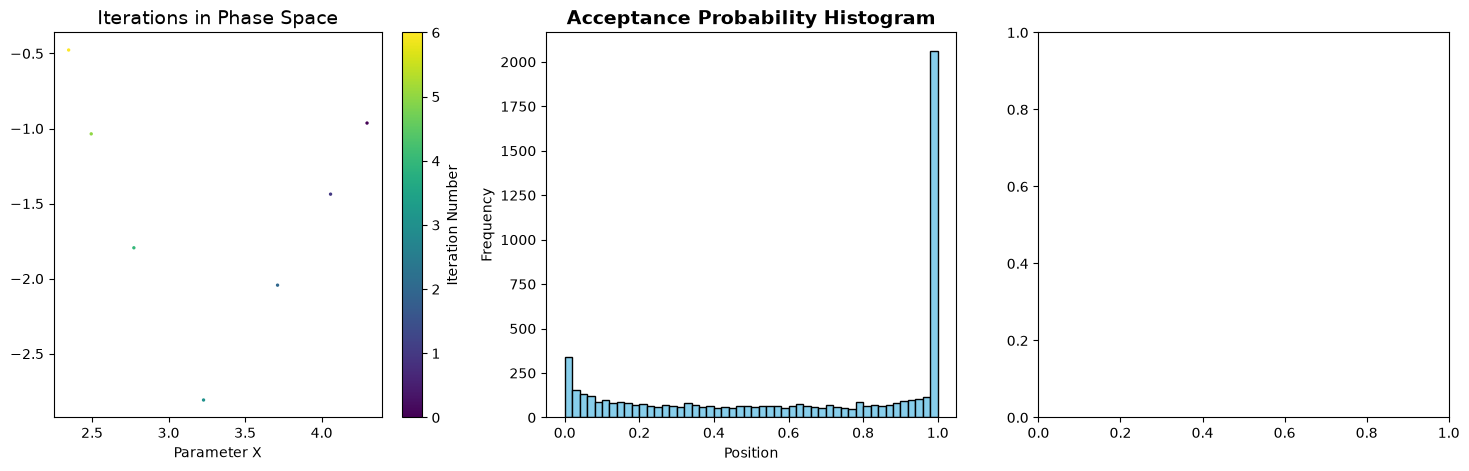

Step Size: 0.2 Num Integration Steps: 6 Inverse Mass Matrix: 1
1.0
1.0001665
KL_divergence is 0.398395299911499


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
density_space = jnp.linspace(-5, 5, 100)
trial_space = jnp.arange(num_overall_steps)

axes[0].plot(density_space, negative_logdensity(density_space))
axes[0].set_title("Log Probability Density")
axes[1].plot(trial_space, overall_position_arr[trial_space])
axes[1].set_title("HMC position vs step")
axes[2].hist(overall_position_arr, bins=50, edgecolor='black', color='skyblue', density = True)
x_vals = np.linspace(-10, 10, 500)
y_vals = jnp.exp(-negative_logdensity(x_vals))
axes[2].plot(x_vals, y_vals, color='red', linewidth=2, label='theoretical density')
axes[2].legend()
# Add labels and a title to make it readable
axes[2].set_title('Position Histogram', fontsize=14, fontweight='bold')

axes[2].set_xlabel('Position')
axes[2].set_ylabel('Frequency')

# Clean up the layout and display the plot
plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
iterations = np.arange(len(one_update_position_arr))
scatter2 = axes2[0].scatter(one_update_position_arr, momentum_arr, 
                         c=iterations, cmap='viridis', alpha=1, s=2)

axes2[0].set_title("Iterations in Phase Space", fontsize=14)
axes2[0].set_xlabel("Parameter X")

# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes2[0], label="Iteration Number") 

axes2[1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes2[1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes2[1].set_xlabel('Position')
axes2[1].set_ylabel('Frequency')

plt.show()

print(f"Step Size: {step_size} Num Integration Steps: {num_integration_steps} Inverse Mass Matrix: {inv_mass_matrix}")
# compute KL divergence 
counts, bin_edges = jnp.histogram(overall_position_arr, bins = np.linspace(-10, 10, 101))
midpoints = (bin_edges[:-1] + bin_edges[1:]) / 2
expected_densities = jnp.exp(-1*negative_logdensity(midpoints))*0.2
actual_densities = counts/num_overall_steps

expected_densities = expected_densities/jnp.sum(expected_densities)


def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)

print(jnp.sum(expected_densities))
print(jnp.sum(actual_densities))
print(f"KL_divergence is {KL_divergence(expected_densities, actual_densities, jitter = 1e-5)}")

